# Model Tuning and Final Model Selection

This notebook tunes promising classification models, compares their
validation performance, investigates an additional BMI feature, and
selects the final obesity classification pipeline.

## Objectives

- Tune Random Forest and Gradient Boosting using RandomizedSearchCV.
- Compare baseline and tuned models on the same validation set.
- Investigate whether adding BMI improves validation performance.
- Select the final model using validation Macro F1.
- Train the selected pipeline on the combined training and validation data.
- Evaluate the final model on the reserved test set.
- Save the fitted pipeline and its metadata for application integration.

## Evaluation Approach

Hyperparameter tuning uses 5-fold cross-validation on the training set.
Macro F1 is the primary scoring metric because it gives equal importance
to each obesity class.

The validation set supports model comparison and the BMI experiment.
The test set is reserved for evaluating the final selected model.

## Import Libraries

This cell imports the tools required for data handling, model tuning,
evaluation, and pipeline construction.

- NumPy and pandas support numerical operations and data handling.
- Scikit-learn provides data splitting, stratified cross-validation,
  hyperparameter search, evaluation metrics, pipelines, and Random Forest.
- Path and sys help locate the project root and import project modules.
- The shared preprocessing module provides the approved predictive
  features and preprocessing configuration.

The project root is added to Python's import path so the notebook
can access the `src` package.

Gradient Boosting, plotting libraries, Joblib, and JSON are imported
later in the notebook where they are needed.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.preprocessing import PREDICTIVE_FEATURES, build_preprocessor

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

print("Project root:", ROOT)
print("src import: OK")

Project root: c:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM
src import: OK


## Configure Project Paths and Reproducibility

This cell locates the project directory and defines the paths used
to load data and save generated results and model artifacts.

A fixed random seed of 42 is used for operations that involve randomness.
This supports reproducible data splits, parameter searches, and training
within the same software environment.

In [2]:
DATA = ROOT / "data"
REPORTS = ROOT / "reports" / "generated"

SEED = 42
TARGET = "NObeyesdad"

CLASSES = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
]

print("ROOT:", ROOT)
print("DATA:", DATA)
print("REPORTS:", REPORTS)
print("SEED:", SEED)
print("TARGET:", TARGET)

ROOT: c:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM
DATA: c:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\data
REPORTS: c:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\reports\generated
SEED: 42
TARGET: NObeyesdad


## Load and Verify the Dataset

The dataset contains 20,758 labelled records, with 16 input features,
an identifier column (`id`), and the target column (`NObeyesdad`).

The following cell loads the CSV file and displays its dimensions
and column names to confirm that the expected dataset is available.

In [3]:
frame = pd.read_csv(DATA / "raw" / "obesity.csv")

print("Shape:", frame.shape)
print("Columns:")
print(frame.columns.tolist())

Shape: (20758, 18)
Columns:
['id', 'Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']


### Separate Predictors and Target

`X` contains the 16 predictive features defined in the shared
preprocessing module. `y` contains the obesity class for each record.

The identifier is excluded because it identifies records rather than
describing a person's characteristics. BMI is excluded from this
initial feature set and will be investigated separately later.

Assertions check that the dataset has the expected number of records,
16 predictors, and seven target classes. If these checks fail,
execution stops so the mismatch can be investigated before training.

In [4]:
X = frame[list(PREDICTIVE_FEATURES)].copy()
y = frame[TARGET].copy()

assert X.shape == (20758, 16)
assert y.nunique() == 7

assert "id" not in X.columns
assert "BMI" not in X.columns

assert list(y.unique())

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of predictors:", X.shape[1])
print("Number of classes:", y.nunique())
print("\nClasses:")
print(sorted(y.unique()))

X shape: (20758, 16)
y shape: (20758,)
Number of predictors: 16
Number of classes: 7

Classes:
['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


## Recreate the Fixed Train, Validation, and Test Split

The dataset is split using the same procedure and random seed (42)
as Notebook 04, ensuring consistent model comparisons.

The split is performed in two stages:
1. Allocate 70% of the data to training.
2. Divide the remaining 30% equally between validation and testing.

The resulting partitions contain:
- Training: 14,530 records.
- Validation: 3,114 records.
- Test: 3,114 records.

Both stages use stratification to approximately preserve the
distribution of the seven obesity classes.

Training data is used for fitting and cross-validation. Validation
data supports model selection and the BMI experiment. Test data is
reserved for the final evaluation.

Assertions verify the partition sizes and confirm that no record
appears in more than one partition.

In [5]:
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=SEED,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp,
    y_tmp,
    test_size=0.50,
    stratify=y_tmp,
    random_state=SEED,
)

assert (len(X_train), len(X_val), len(X_test)) == (
    14530,
    3114,
    3114,
)

assert set(X_train.index).isdisjoint(X_val.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_val.index).isdisjoint(X_test.index)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (14530, 16)
Validation: (3114, 16)
Test: (3114, 16)


### Save the Reserved Test Partition

The test features and labels are saved as separate CSV files in
`data/processed` for reuse during explainability analysis and testing.

Saving the files does not fit or evaluate a model. Their row order
is preserved so each feature record remains aligned with its label.

In [6]:
from pathlib import Path

data_dir = Path("../data/processed")
data_dir.mkdir(parents=True, exist_ok=True)

X_test.to_csv(
    data_dir / "X_test.csv",
    index=False
)

y_test.to_csv(
    data_dir / "y_test.csv",
    index=False
)

print("Test data saved successfully")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Test data saved successfully
X_test: (3114, 16)
y_test: (3114,)


## Define Shared Evaluation Metrics

The `scores()` function calculates the same four metrics for each
model, ensuring consistent comparisons.

- **Accuracy:** The proportion of predictions that are correct.
- **Balanced Accuracy:** The average recall across the seven classes,
  giving each class equal importance.
- **Macro F1:** The average class-level F1 score, giving each class
  equal importance when combining precision and recall.
- **Weighted F1:** The average class-level F1 score weighted by the
  number of actual records in each class.

Macro F1 is the primary metric for tuning and model selection.
The other metrics provide supporting views of performance.

The function returns the model name and its scores as a dictionary
that can be combined with other results in a comparison table.

For F1 calculations, `zero_division=0` assigns zero when a class-level
calculation is undefined.

In [7]:
def scores(name, actual, predicted):
    return {
        "Model": name,
        "Accuracy": accuracy_score(actual, predicted),
        "Balanced Accuracy": balanced_accuracy_score(actual, predicted),
        "Macro F1": f1_score(
            actual,
            predicted,
            average="macro",
            zero_division=0,
        ),
        "Weighted F1": f1_score(
            actual,
            predicted,
            average="weighted",
            zero_division=0,
        ),
    }

## Verify the Notebook 04 Handoff

This cell loads two reports produced by Notebook 04:

- `baseline_model_comparison.csv`: evaluation results for the five
  baseline models, including the dummy classifier.
- `tuning_candidates.csv`: the two models selected for tuning.

Assertions confirm that the reports contain five baseline results
and two tuning candidates: Random Forest and Gradient Boosting.

Both reports are displayed so the team can review the baseline
results and confirm the models being carried forward.

In [8]:
baseline_report = pd.read_csv(
    REPORTS / "baseline_model_comparison.csv"
)

candidate_report = pd.read_csv(
    REPORTS / "tuning_candidates.csv"
)

assert len(baseline_report) == 5
assert len(candidate_report) == 2

assert set(candidate_report["Model"]) == {
    "Random Forest",
    "Gradient Boosting",
}

print("Baseline report:")
display(baseline_report)

print("\nTuning candidates:")
display(candidate_report)

Baseline report:


,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro F1 Rank,Balanced Accuracy Rank,Accuracy Rank
0,Gradient Boosting,0.903340,0.893142,0.893031,0.902952,1,1,1
1,Random Forest,0.895633,0.884543,0.884858,0.895254,2,2,2
2,Logistic Regression,0.858060,0.843242,0.841809,0.856599,3,3,3
3,Decision Tree,0.845215,0.831168,0.830801,0.845645,4,4,4
4,Dummy Classifier,0.194926,0.142857,0.046608,0.063596,5,5,5



Tuning candidates:


,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Training Macro F1,Macro F1 Gap
0,Gradient Boosting,0.903340,0.893142,0.893031,0.902952,0.912625,0.019594
1,Random Forest,0.895633,0.884543,0.884858,0.895254,1.000000,0.115142


## Configure Shared Cross-Validation

Both models use the same five-fold stratified cross-validation
configuration to support consistent comparisons.

Stratification approximately preserves the class distribution
within each fold. Shuffling with random seed 42 makes the fold
assignment reproducible within the same software environment.

RandomizedSearchCV evaluates 20 parameter combinations across
five folds, producing 100 cross-validation fits per model.

Four metrics are recorded: Accuracy, Balanced Accuracy, Macro F1,
and Weighted F1. `refit="macro_f1"` selects the configuration with
the highest mean cross-validation Macro F1 and refits it on the
complete training partition.

Training scores are also recorded to help assess overfitting.
Validation and test data are excluded from this search.

In [9]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

SCORING = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
}

SEARCH_CONFIG = dict(
    n_iter=20,
    scoring=SCORING,
    refit="macro_f1",
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

print("CV:", cv)
print("Search configuration:")
print(SEARCH_CONFIG)

CV: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
Search configuration:
{'n_iter': 20, 'scoring': {'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy', 'macro_f1': 'f1_macro', 'weighted_f1': 'f1_weighted'}, 'refit': 'macro_f1', 'cv': StratifiedKFold(n_splits=5, random_state=42, shuffle=True), 'random_state': 42, 'n_jobs': -1, 'verbose': 1, 'return_train_score': True}


## Define the Random Forest Search Space

The search investigates six hyperparameters:

- `n_estimators`: the number of trees.
- `max_depth`: the maximum depth of each tree.
- `min_samples_split`: the minimum number of samples required
  to split an internal node.
- `min_samples_leaf`: the minimum number of samples in a leaf.
- `max_features`: the number or proportion of features considered
  when finding a split.
- `class_weight`: whether class weights are adjusted for imbalance.

These parameters influence model complexity, generalisation,
and the treatment of class imbalance.

The `classifier__` prefix identifies parameters belonging to the
classifier step inside the pipeline. RandomizedSearchCV samples
20 combinations from the listed values.

In [10]:
rf_params = {
    "classifier__n_estimators": [150, 200, 300, 400],
    "classifier__max_depth": [None, 10, 15, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2", 0.5],
    "classifier__class_weight": [
        None,
        "balanced",
        "balanced_subsample",
    ],
}

print("Random Forest hyperparameters:")

for parameter, values in rf_params.items():
    print(f"{parameter}: {values}")

Random Forest hyperparameters:
classifier__n_estimators: [150, 200, 300, 400]
classifier__max_depth: [None, 10, 15, 20, 30]
classifier__min_samples_split: [2, 5, 10]
classifier__min_samples_leaf: [1, 2, 4]
classifier__max_features: ['sqrt', 'log2', 0.5]
classifier__class_weight: [None, 'balanced', 'balanced_subsample']


## Build the Random Forest Pipeline

The pipeline combines the shared preprocessing procedure with
a Random Forest classifier.

During cross-validation, preprocessing is fitted separately on
each training fold and then applied to its held-out fold. This
prevents the held-out records from influencing fitted preprocessing.

Random seed 42 controls the classifier's randomness.
The classifier uses `n_jobs=1` because RandomizedSearchCV already
runs search fits in parallel with `n_jobs=-1`.

In [11]:
rf_pipe = Pipeline([
    (
        "preprocessor",
        build_preprocessor(),
    ),
    (
        "classifier",
        RandomForestClassifier(
            random_state=SEED,
            n_jobs=1,
        ),
    ),
])

print(rf_pipe)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
              

## Tune Random Forest

RandomizedSearchCV evaluates 20 sampled hyperparameter combinations
using five-fold cross-validation on the training partition.

The configuration with the highest mean cross-validation Macro F1
is selected and refitted on the complete training partition.

This cell displays the best cross-validation score and the selected
hyperparameters. The separate validation and test sets are not
used during this search.

In [12]:
rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_params,
    **SEARCH_CONFIG,
)

rf_search.fit(X_train, y_train)

print("\nBest CV Macro F1:", rf_search.best_score_)

print("\nBest parameters:")
for parameter, value in rf_search.best_params_.items():
    print(f"{parameter}: {value}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best CV Macro F1: 0.8871945443237207

Best parameters:
classifier__n_estimators: 150
classifier__min_samples_split: 10
classifier__min_samples_leaf: 2
classifier__max_features: 0.5
classifier__max_depth: 20
classifier__class_weight: None


### Confirm Search Completion

This cell displays the number of evaluated configurations, the best
cross-validation Macro F1, and the type of the selected estimator.

The expected candidate count is 20. The selected estimator is a
pipeline containing preprocessing and the Random Forest classifier.

In [13]:
print("Search Completed")
print("Number of candidates evaluated:", len(rf_search.cv_results_["params"]))
print("Best CV Macro F1:", rf_search.best_score_)
print(
    "Best estimator:",
    type(rf_search.best_estimator_).__name__,
)

Search Completed
Number of candidates evaluated: 20
Best CV Macro F1: 0.8871945443237207
Best estimator: Pipeline


## Inspect Random Forest Cross-Validation Results

The search results are converted into a table containing all
20 evaluated configurations. The ten highest-ranked configurations
are displayed.

The table includes:
- Mean held-out fold Macro F1.
- Standard deviation of held-out fold Macro F1.
- Mean training fold Macro F1.
- The difference between training and held-out fold Macro F1.

A larger positive difference can indicate overfitting. The standard
deviation shows how much performance varies across folds.

Here, `mean_test_macro_f1` refers to held-out cross-validation folds,
not the reserved test partition.

In [14]:
rf_full = pd.DataFrame(rf_search.cv_results_)

rf_full["CV Macro F1 Gap"] = (
    rf_full["mean_train_macro_f1"]
    - rf_full["mean_test_macro_f1"]
)

display(
    rf_full.sort_values("rank_test_macro_f1")[
        [
            "rank_test_macro_f1",
            "mean_test_macro_f1",
            "std_test_macro_f1",
            "mean_train_macro_f1",
            "CV Macro F1 Gap",
        ]
    ].head(10)
)

,rank_test_macro_f1,mean_test_macro_f1,std_test_macro_f1,mean_train_macro_f1,CV Macro F1 Gap
16,1,0.887195,0.006269,0.945690,0.058495
11,2,0.886963,0.007043,0.961480,0.074517
19,3,0.886837,0.005373,0.990737,0.103900
5,4,0.886473,0.005926,0.973483,0.087010
6,5,0.886214,0.006193,0.984819,0.098605
10,6,0.886116,0.005648,0.955806,0.069691
4,7,0.885899,0.006474,0.985111,0.099212
15,8,0.882728,0.006944,0.987813,0.105086
14,9,0.881169,0.006762,0.971862,0.090693
3,10,0.880857,0.007010,0.937826,0.056969


## Evaluate Tuned Random Forest on the Validation Set

The selected Random Forest pipeline predicts the separate validation
records. Its Accuracy, Balanced Accuracy, Macro F1, and Weighted F1
are calculated using the shared evaluation function.

Validation Macro F1 is compared with the Random Forest baseline
from Notebook 04 to determine whether tuning improved performance.

A positive change indicates improvement; a negative change indicates
a decrease. These scores support the later model comparison.
The reserved test partition remains unused at this stage.

In [15]:
rf_val = scores(
    "Random Forest",
    y_val,
    rf_search.best_estimator_.predict(X_val),
)

base_rf = baseline_report.set_index("Model").loc[
    "Random Forest",
    "Macro F1",
]

print("Baseline RF Macro F1:", base_rf)
print("Tuned RF Macro F1:", rf_val["Macro F1"])
print("Change:", rf_val["Macro F1"] - base_rf)

print("\nTuned Random Forest validation metrics:")
display(pd.DataFrame([rf_val]))

Baseline RF Macro F1: 0.8848580437360324
Tuned RF Macro F1: 0.8966909775993644
Change: 0.011832933863332062

Tuned Random Forest validation metrics:


,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1
0,Random Forest,0.905909,0.896718,0.896691,0.905611


## Export Random Forest Tuning Results

All 20 configurations are ranked by cross-validation Macro F1 and
saved to `reports/generated/random_forest_tuning_results.csv`.

The report includes cross-validation metrics, training Macro F1,
mean fit time, and the hyperparameter values for each configuration.

The exported results allow team members to inspect the search and
document the selected configuration. An assertion verifies that
all 20 configurations are included.

In [16]:
cv_cols = [
    "rank_test_macro_f1",
    "mean_test_macro_f1",
    "std_test_macro_f1",
    "mean_train_macro_f1",
    "mean_test_accuracy",
    "mean_test_balanced_accuracy",
    "mean_test_weighted_f1",
    "mean_fit_time",
]

rf_cols = cv_cols + [
    "param_" + parameter
    for parameter in rf_params
]

rf_report = rf_full.sort_values(
    "rank_test_macro_f1"
)[rf_cols]

rf_report.to_csv(
    REPORTS / "random_forest_tuning_results.csv",
    index=False,
)

assert len(rf_report) == 20

print(
    "Saved:",
    REPORTS / "random_forest_tuning_results.csv",
)

print("Rows exported:", len(rf_report))
print("Columns exported:", len(rf_report.columns))

display(rf_report.head())

Saved: c:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\reports\generated\random_forest_tuning_results.csv
Rows exported: 20
Columns exported: 14


,rank_test_macro_f1,mean_test_macro_f1,std_test_macro_f1,mean_train_macro_f1,mean_test_accuracy,mean_test_balanced_accuracy,mean_test_weighted_f1,mean_fit_time,param_classifier__n_estimators,param_classifier__max_depth,param_classifier__min_samples_split,param_classifier__min_samples_leaf,param_classifier__max_features,param_classifier__class_weight
16,1,0.887195,0.006269,0.945690,0.898348,0.887002,0.898087,6.479539,150,20,10,2,0.5,NaN
11,2,0.886963,0.007043,0.961480,0.897935,0.886987,0.897839,6.744589,150,15,5,2,0.5,balanced
19,3,0.886837,0.005373,0.990737,0.898004,0.886655,0.897763,7.224702,200,15,2,1,0.5,NaN
5,4,0.886473,0.005926,0.973483,0.897591,0.886496,0.897428,8.748445,200,None,2,2,0.5,balanced_subsample
6,5,0.886214,0.006193,0.984819,0.897385,0.886230,0.897230,9.462130,200,30,5,1,0.5,balanced_subsample


## Verify Random Forest Tuning Outputs

Assertions check that:
- Exactly 20 hyperparameter configurations were evaluated.
- Macro F1 was used to select and refit the best configuration.
- The exported report contains 20 rows and the expected columns.
- The training, validation, and test partition sizes remain correct.

If an assertion fails, execution stops so the mismatch can be
investigated before continuing.

These checks verify the search configuration and output structure.
The preceding code ensures that only training data is passed
to the hyperparameter search.

In [17]:
assert len(rf_search.cv_results_["params"]) == 20
assert rf_search.refit == "macro_f1"
assert len(rf_report) == 20
assert set(rf_report.columns) == set(rf_cols)

assert len(X_train) == 14530
assert len(X_val) == 3114
assert len(X_test) == 3114

print("20 RF configurations: PASS")
print("Macro F1 refit: PASS")
print("RF tuning report: PASS")
print("Train/validation/test split: PASS")
print("Part A Random Forest tuning workflow: COMPLETE")

20 RF configurations: PASS
Macro F1 refit: PASS
RF tuning report: PASS
Train/validation/test split: PASS
Part A Random Forest tuning workflow: COMPLETE


## Carry Forward the Random Forest Results

The following objects remain available for the next stages:

- `rf_search`: the fitted search object and selected pipeline.
- `rf_full`: the complete cross-validation results.
- `rf_val`: the selected pipeline's validation metrics.
- `rf_report`: the results table saved as a CSV file.
- `SEARCH_CONFIG`: the shared hyperparameter search settings.
- `cv`: the shared stratified cross-validation configuration.

Gradient Boosting will use the same data partitions, scoring metrics,
and cross-validation configuration to support consistent comparisons.

The Random Forest report is saved at:
`reports/generated/random_forest_tuning_results.csv`.

The reserved test set remains unused at this stage.

## Summarise Random Forest Tuning

This cell displays the best cross-validation Macro F1, selected
hyperparameters, validation metrics, and the change in validation
Macro F1 compared with the baseline.

The summary helps the team explain what tuning selected and whether
it improved performance on the separate validation set.

Random Forest is still a candidate at this stage. Final model
selection takes place after the Gradient Boosting results are
available for comparison.

In [18]:
print("===== RANDOM FOREST TUNING SUMMARY =====")

print(f"Best CV Macro F1: {rf_search.best_score_:.6f}")

print("\nBest parameters:")
for parameter, value in rf_search.best_params_.items():
    print(f"  {parameter}: {value}")

print("\nValidation metrics:")
for metric, value in rf_val.items():
    if metric != "Model":
        print(f"  {metric}: {value:.6f}")

print("\nBaseline RF Macro F1:", f"{base_rf:.6f}")
print("Tuned RF Macro F1:", f"{rf_val['Macro F1']:.6f}")
print(
    "Validation Macro F1 change:",
    f"{rf_val['Macro F1'] - base_rf:+.6f}"
)

===== RANDOM FOREST TUNING SUMMARY =====
Best CV Macro F1: 0.887195

Best parameters:
  classifier__n_estimators: 150
  classifier__min_samples_split: 10
  classifier__min_samples_leaf: 2
  classifier__max_features: 0.5
  classifier__max_depth: 20
  classifier__class_weight: None

Validation metrics:
  Accuracy: 0.905909
  Balanced Accuracy: 0.896718
  Macro F1: 0.896691
  Weighted F1: 0.905611

Baseline RF Macro F1: 0.884858
Tuned RF Macro F1: 0.896691
Validation Macro F1 change: +0.011833


## Review the Highest-Ranked Random Forest Configurations

This table displays the ten highest-ranked configurations according
to mean cross-validation Macro F1.

Training scores and the training-to-held-out-fold score gap help
identify possible overfitting. The standard deviation indicates
how much held-out performance varies across the five folds.

These are cross-validation results, not reserved test-set results.

In [19]:
top_rf = rf_full.sort_values(
    "rank_test_macro_f1"
).copy()

top_rf[
    [
        "rank_test_macro_f1",
        "mean_test_macro_f1",
        "std_test_macro_f1",
        "mean_train_macro_f1",
        "CV Macro F1 Gap",
    ]
].head(10)

,rank_test_macro_f1,mean_test_macro_f1,std_test_macro_f1,mean_train_macro_f1,CV Macro F1 Gap
16,1,0.887195,0.006269,0.945690,0.058495
11,2,0.886963,0.007043,0.961480,0.074517
19,3,0.886837,0.005373,0.990737,0.103900
5,4,0.886473,0.005926,0.973483,0.087010
6,5,0.886214,0.006193,0.984819,0.098605
10,6,0.886116,0.005648,0.955806,0.069691
4,7,0.885899,0.006474,0.985111,0.099212
15,8,0.882728,0.006944,0.987813,0.105086
14,9,0.881169,0.006762,0.971862,0.090693
3,10,0.880857,0.007010,0.937826,0.056969


## Verify the Saved Random Forest Report

The exported CSV is loaded again to confirm that it exists and
contains the expected 20 configurations and 14 columns.

The first rows are displayed so the team can inspect the saved
report. These checks verify the saved file's structure.

In [20]:
rf_output = REPORTS / "random_forest_tuning_results.csv"

assert rf_output.exists()

saved_rf_report = pd.read_csv(rf_output)

assert len(saved_rf_report) == 20
assert len(saved_rf_report.columns) == 14

print("File exists:", rf_output.exists())
print("Rows:", len(saved_rf_report))
print("Columns:", len(saved_rf_report.columns))

display(saved_rf_report.head())

File exists: True
Rows: 20
Columns: 14


,rank_test_macro_f1,mean_test_macro_f1,std_test_macro_f1,mean_train_macro_f1,mean_test_accuracy,mean_test_balanced_accuracy,mean_test_weighted_f1,mean_fit_time,param_classifier__n_estimators,param_classifier__max_depth,param_classifier__min_samples_split,param_classifier__min_samples_leaf,param_classifier__max_features,param_classifier__class_weight
0,1,0.887195,0.006269,0.945690,0.898348,0.887002,0.898087,6.479539,150,20.0,10,2,0.5,NaN
1,2,0.886963,0.007043,0.961480,0.897935,0.886987,0.897839,6.744589,150,15.0,5,2,0.5,balanced
2,3,0.886837,0.005373,0.990737,0.898004,0.886655,0.897763,7.224702,200,15.0,2,1,0.5,NaN
3,4,0.886473,0.005926,0.973483,0.897591,0.886496,0.897428,8.748445,200,NaN,2,2,0.5,balanced_subsample
4,5,0.886214,0.006193,0.984819,0.897385,0.886230,0.897230,9.462130,200,30.0,5,1,0.5,balanced_subsample


## Gradient Boosting Hyperparameter Tuning

Gradient Boosting builds trees sequentially, with each stage
learning to improve the current model's predictions.

The search investigates seven hyperparameters:
- `n_estimators`: the number of boosting stages.
- `learning_rate`: the contribution of each stage.
- `max_depth`: the maximum depth of each tree.
- `min_samples_split`: the minimum samples required for a split.
- `min_samples_leaf`: the minimum samples in a leaf.
- `subsample`: the proportion of training samples used per stage.
- `max_features`: the features considered when finding a split.

The search uses the same data partitions, scoring metrics, and
cross-validation configuration as Random Forest.

In [21]:
from sklearn.ensemble import GradientBoostingClassifier

gb_params = {
    "classifier__n_estimators": [75, 100, 150, 200],
    "classifier__learning_rate": [0.03, 0.05, 0.10, 0.15],
    "classifier__max_depth": [2, 3, 4],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__subsample": [0.8, 0.9, 1.0],
    "classifier__max_features": [None, "sqrt", 0.8],
}

print("Gradient Boosting hyperparameters:")

for parameter, values in gb_params.items():
    print(f"{parameter}: {values}")

Gradient Boosting hyperparameters:
classifier__n_estimators: [75, 100, 150, 200]
classifier__learning_rate: [0.03, 0.05, 0.1, 0.15]
classifier__max_depth: [2, 3, 4]
classifier__min_samples_split: [2, 5, 10]
classifier__min_samples_leaf: [1, 2, 4]
classifier__subsample: [0.8, 0.9, 1.0]
classifier__max_features: [None, 'sqrt', 0.8]


### Build the Gradient Boosting Pipeline

The pipeline combines the shared preprocessing procedure with
a Gradient Boosting classifier.

Preprocessing is fitted within each cross-validation training
fold, preventing held-out records from influencing its fitted
transformations.

The fixed random seed supports reproducible training within
the same software environment.

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

gb_pipe = Pipeline([
    (
        "preprocessor",
        build_preprocessor(),
    ),
    (
        "classifier",
        GradientBoostingClassifier(
            random_state=SEED,
        ),
    ),
])

print(gb_pipe)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
              

### Run the Gradient Boosting Search

RandomizedSearchCV evaluates 20 sampled configurations using
five-fold stratified cross-validation on the training partition.

The configuration with the highest mean cross-validation Macro F1
is selected and refitted on the complete training partition.

The cell displays the selected parameters, best cross-validation
score, and number of evaluated configurations.

The separate validation and test sets are excluded from the search.

In [23]:
gb_search = RandomizedSearchCV(
    estimator=gb_pipe,
    param_distributions=gb_params,
    **SEARCH_CONFIG,
)

gb_search.fit(X_train, y_train)

print("\nBest CV Macro F1:", gb_search.best_score_)

print("\nBest parameters:")
for parameter, value in gb_search.best_params_.items():
    print(f"{parameter}: {value}")

print("\nNumber of candidates evaluated:", len(gb_search.cv_results_["params"]))


Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best CV Macro F1: 0.8919679674011272

Best parameters:
classifier__subsample: 0.8
classifier__n_estimators: 100
classifier__min_samples_split: 5
classifier__min_samples_leaf: 2
classifier__max_features: 0.8
classifier__max_depth: 3
classifier__learning_rate: 0.15

Number of candidates evaluated: 20


### Evaluate Gradient Boosting on the Validation Set

The selected pipeline predicts the separate validation records.

Accuracy, Balanced Accuracy, Macro F1, and Weighted F1 summarise
overall performance. The classification report provides precision,
recall, F1, and support for each obesity class.

These validation results will support comparison with the baseline
and Random Forest models.

In [24]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

gb_val_pred = gb_search.best_estimator_.predict(X_val)

gb_val_accuracy = accuracy_score(y_val, gb_val_pred)
gb_val_balanced_accuracy = balanced_accuracy_score(y_val, gb_val_pred)
gb_val_macro_f1 = f1_score(y_val, gb_val_pred, average="macro")
gb_val_weighted_f1 = f1_score(y_val, gb_val_pred, average="weighted")

print("Tuned Gradient Boosting - Validation Results")
print(f"Accuracy:           {gb_val_accuracy:.6f}")
print(f"Balanced Accuracy:  {gb_val_balanced_accuracy:.6f}")
print(f"Macro F1:            {gb_val_macro_f1:.6f}")
print(f"Weighted F1:         {gb_val_weighted_f1:.6f}")

print("\nClassification Report:")
print(classification_report(y_val, gb_val_pred))

Tuned Gradient Boosting - Validation Results
Accuracy:           0.907514
Balanced Accuracy:  0.897894
Macro F1:            0.897776
Weighted F1:         0.907099

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.92      0.95      0.94       379
      Normal_Weight       0.90      0.89      0.89       463
     Obesity_Type_I       0.88      0.88      0.88       436
    Obesity_Type_II       0.95      0.96      0.96       487
   Obesity_Type_III       1.00      1.00      1.00       607
 Overweight_Level_I       0.84      0.77      0.80       364
Overweight_Level_II       0.81      0.83      0.82       378

           accuracy                           0.91      3114
          macro avg       0.90      0.90      0.90      3114
       weighted avg       0.91      0.91      0.91      3114



### Inspect the Validation Confusion Matrix

The confusion matrix shows which classes the model predicts
correctly and which classes it confuses.

Rows represent actual classes, and columns represent predicted
classes. Diagonal entries are correct predictions; off-diagonal
entries are classification errors.

This helps the team identify class-specific weaknesses that
overall metrics may hide.

In [25]:
class_names = sorted(y_val.unique())

gb_val_cm = confusion_matrix(y_val, gb_val_pred)

print("Confusion Matrix:")

display(
    pd.DataFrame(
        gb_val_cm,
        index=class_names,
        columns=class_names,
    )
)

Confusion Matrix:


,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Insufficient_Weight,360,16,0,0,0,3,0
Normal_Weight,29,412,0,0,0,18,4
Obesity_Type_I,1,1,385,20,1,6,22
Obesity_Type_II,0,0,17,469,0,1,0
Obesity_Type_III,0,0,1,1,605,0,0
Overweight_Level_I,1,26,8,0,0,282,47
Overweight_Level_II,0,5,29,4,0,27,313


### Save the Gradient Boosting Search Results

All 20 evaluated configurations are ordered by cross-validation
Macro F1 rank and saved to:

`reports/generated/gradient_boosting_tuning_results.csv`

The report retains the search parameters, fold-level scores,
summary scores, and timing information for later inspection
and documentation.

In [26]:
gb_results = pd.DataFrame(gb_search.cv_results_)

gb_results = gb_results.sort_values(
    by="rank_test_macro_f1"
).reset_index(drop=True)

gb_output = REPORTS / "gradient_boosting_tuning_results.csv"

gb_results.to_csv(
    gb_output,
    index=False,
)

print("Saved:", gb_output)

Saved: c:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\reports\generated\gradient_boosting_tuning_results.csv


### Organise Gradient Boosting Validation Metrics

The four validation metrics are collected into a dictionary
labelled `Gradient Boosting - Tuned`.

This cell organises and displays scores that were already
calculated. It does not train or evaluate the model again.

In [27]:
# ============================================================
# Part B — Compare Baseline and Tuned Models
# ============================================================

# Tuned Gradient Boosting validation metrics
gb_tuned_metrics = {
    "Model": "Gradient Boosting - Tuned",
    "Accuracy": gb_val_accuracy,
    "Balanced Accuracy": gb_val_balanced_accuracy,
    "Macro F1": gb_val_macro_f1,
    "Weighted F1": gb_val_weighted_f1,
}

print("Tuned Gradient Boosting:")
for metric, value in gb_tuned_metrics.items():
    if metric != "Model":
        print(f"{metric}: {value:.6f}")

Tuned Gradient Boosting:
Accuracy: 0.907514
Balanced Accuracy: 0.897894
Macro F1: 0.897776
Weighted F1: 0.907099


### Review Class-Level Validation Performance

The classification report displays:
- Precision: how often predictions of a class are correct.
- Recall: how many actual records of a class are identified.
- F1: the harmonic mean of precision and recall.
- Support: the number of actual validation records in each class.

Class-level scores help identify uneven performance across
the seven obesity categories. Values are displayed to two
decimal places.

In [28]:
print(
    classification_report(
        y_val,
        gb_val_pred,
        target_names=class_names,
        digits=2
    )
)

                     precision    recall  f1-score   support

Insufficient_Weight       0.92      0.95      0.94       379
      Normal_Weight       0.90      0.89      0.89       463
     Obesity_Type_I       0.88      0.88      0.88       436
    Obesity_Type_II       0.95      0.96      0.96       487
   Obesity_Type_III       1.00      1.00      1.00       607
 Overweight_Level_I       0.84      0.77      0.80       364
Overweight_Level_II       0.81      0.83      0.82       378

           accuracy                           0.91      3114
          macro avg       0.90      0.90      0.90      3114
       weighted avg       0.91      0.91      0.91      3114



## Compare Baseline and Tuned Models

The baseline results from Notebook 04 are loaded for comparison
with the tuned models.

Random Forest and Gradient Boosting are compared before and after
tuning using the same validation partition. Macro F1 is the primary
selection metric; the other metrics provide supporting evidence.

The reserved test set is excluded from model selection.

In [29]:
baseline_results = pd.read_csv(
    REPORTS / "baseline_model_comparison.csv"
)

display(baseline_results)

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro F1 Rank,Balanced Accuracy Rank,Accuracy Rank
0,Gradient Boosting,0.903340,0.893142,0.893031,0.902952,1,1,1
1,Random Forest,0.895633,0.884543,0.884858,0.895254,2,2,2
2,Logistic Regression,0.858060,0.843242,0.841809,0.856599,3,3,3
3,Decision Tree,0.845215,0.831168,0.830801,0.845645,4,4,4
4,Dummy Classifier,0.194926,0.142857,0.046608,0.063596,5,5,5


### Prepare Tuned Gradient Boosting Scores for Comparison

The previously calculated validation scores are organised under
the label `Gradient Boosting - Tuned`.

This dictionary supplies the Gradient Boosting tuning results
to the joint comparison table. No additional training occurs here.

In [30]:
gb_val_metrics = {
    "Model": "Gradient Boosting - Tuned",
    "Accuracy": gb_val_accuracy,
    "Balanced Accuracy": gb_val_balanced_accuracy,
    "Macro F1": gb_val_macro_f1,
    "Weighted F1": gb_val_weighted_f1,
}

print("Tuned Gradient Boosting:")
for metric, value in gb_val_metrics.items():
    if metric != "Model":
        print(f"{metric}: {value:.6f}")

Tuned Gradient Boosting:
Accuracy: 0.907514
Balanced Accuracy: 0.897894
Macro F1: 0.897776
Weighted F1: 0.907099


### Build the Four-Candidate Comparison Table

The table combines validation results for:
- Random Forest — Baseline.
- Random Forest — Tuned.
- Gradient Boosting — Baseline.
- Gradient Boosting — Tuned.

Comparing each model before and after tuning shows whether the
parameter search improved validation performance. Comparing
across model families supports final model selection.

In [31]:
# ============================================================
# Model Comparison — Baseline vs Tuned
# ============================================================

# Extract baseline model results
rf_baseline = baseline_results[
    baseline_results["Model"] == "Random Forest"
].iloc[0]

gb_baseline = baseline_results[
    baseline_results["Model"] == "Gradient Boosting"
].iloc[0]

# Create comparison table
comparison_results = pd.DataFrame([
    {
        "Model": "Random Forest - Baseline",
        "Accuracy": rf_baseline["Accuracy"],
        "Balanced Accuracy": rf_baseline["Balanced Accuracy"],
        "Macro F1": rf_baseline["Macro F1"],
        "Weighted F1": rf_baseline["Weighted F1"],
    },
    {
        "Model": "Random Forest - Tuned",
        "Accuracy": rf_val["Accuracy"],
        "Balanced Accuracy": rf_val["Balanced Accuracy"],
        "Macro F1": rf_val["Macro F1"],
        "Weighted F1": rf_val["Weighted F1"],
    },
    {
        "Model": "Gradient Boosting - Baseline",
        "Accuracy": gb_baseline["Accuracy"],
        "Balanced Accuracy": gb_baseline["Balanced Accuracy"],
        "Macro F1": gb_baseline["Macro F1"],
        "Weighted F1": gb_baseline["Weighted F1"],
    },
    {
        "Model": "Gradient Boosting - Tuned",
        "Accuracy": gb_val_metrics["Accuracy"],
        "Balanced Accuracy": gb_val_metrics["Balanced Accuracy"],
        "Macro F1": gb_val_metrics["Macro F1"],
        "Weighted F1": gb_val_metrics["Weighted F1"],
    },
])

display(comparison_results)

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1
0,Random Forest - Baseline,0.895633,0.884543,0.884858,0.895254
1,Random Forest - Tuned,0.905909,0.896718,0.896691,0.905611
2,Gradient Boosting - Baseline,0.903340,0.893142,0.893031,0.902952
3,Gradient Boosting - Tuned,0.907514,0.897894,0.897776,0.907099


### Save the Model Comparison

The four-candidate comparison is saved to:
`reports/generated/model_tuning_comparison.csv`.

This report preserves the validation evidence used to select
the final model and supports the team's report and presentation.

In [32]:
comparison_output = REPORTS / "model_tuning_comparison.csv"

comparison_results.to_csv(
    comparison_output,
    index=False
)

print(
    "Saved:",
    comparison_output
)

Saved: c:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\reports\generated\model_tuning_comparison.csv


## BMI Feature Engineering Experiment

BMI is calculated as weight in kilograms divided by height
in metres squared.

This experiment investigates whether explicitly adding BMI
improves a Gradient Boosting model using the original predictors.

Separate copies of the training and validation features are
created so the original 16-feature datasets remain unchanged.
Adding BMI produces 17 input features.

Assertions verify the expected feature counts and confirm that
BMI has not been added to the original training dataset.

In [33]:
# Create separate copies for the BMI experiment
X_train_bmi = X_train.copy()
X_val_bmi = X_val.copy()

# Calculate BMI using available measurements
X_train_bmi["BMI"] = (
    X_train_bmi["Weight"] / X_train_bmi["Height"] ** 2
)

X_val_bmi["BMI"] = (
    X_val_bmi["Weight"] / X_val_bmi["Height"] ** 2
)

print("Original predictors:", X_train.shape[1])
print("Predictors with BMI:", X_train_bmi.shape[1])

assert X_train.shape[1] == 16
assert X_train_bmi.shape[1] == 17
assert "BMI" not in X_train.columns

Original predictors: 16
Predictors with BMI: 17


### Include BMI in Experimental Preprocessing

A separate preprocessing configuration is created by adding
BMI to the numerical feature list.

The existing numerical and categorical transformations are
retained. The shared preprocessing configuration is not modified.

Assertions confirm that BMI is included and that the experimental
numerical feature list contains nine features.

In [34]:
from sklearn.compose import ColumnTransformer

# Build preprocessing that includes BMI
bmi_transformers = []

for name, transformer, columns in build_preprocessor().transformers:
    selected_columns = list(columns)

    if name == "numerical":
        selected_columns.append("BMI")

    bmi_transformers.append(
        (name, transformer, selected_columns)
    )

bmi_preprocessor = ColumnTransformer(
    transformers=bmi_transformers,
    remainder="drop",
)

print("Numerical features in the BMI experiment:")

for name, transformer, columns in bmi_preprocessor.transformers:
    if name == "numerical":
        print(columns)
        assert "BMI" in columns
        assert len(columns) == 9

Numerical features in the BMI experiment:
['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']


### Train the Original and BMI Pipelines

Two fresh pipelines use identical classifier hyperparameters
from the tuned Gradient Boosting model.

One pipeline uses the original 16 predictors. The other uses
the same predictors plus BMI. Both are fitted on training data
and predict the same validation records.

Keeping the classifier settings and data partitions consistent
isolates the effect of adding BMI under this configuration.
The BMI pipeline is not separately tuned.

Preprocessing produces 25 features for the original pipeline
and 26 for the BMI pipeline.

In [35]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline

# Use the same tuned classifier settings for both experiments
experiment_classifier = (
    gb_search.best_estimator_.named_steps["classifier"]
)

original_experiment = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("classifier", clone(experiment_classifier)),
])

bmi_experiment = Pipeline([
    ("preprocessor", bmi_preprocessor),
    ("classifier", clone(experiment_classifier)),
])

# Fit both pipelines using training data only
original_experiment.fit(X_train, y_train)
bmi_experiment.fit(X_train_bmi, y_train)

# Predict the same validation records
original_val_pred = original_experiment.predict(X_val)
bmi_val_pred = bmi_experiment.predict(X_val_bmi)

print("Both experimental models trained successfully")

print(
    "Original transformed features:",
    len(
        original_experiment.named_steps["preprocessor"]
        .get_feature_names_out()
    ),
)

print(
    "BMI transformed features:",
    len(
        bmi_experiment.named_steps["preprocessor"]
        .get_feature_names_out()
    ),
)

Both experimental models trained successfully
Original transformed features: 25
BMI transformed features: 26


### Evaluate and Save the BMI Comparison

Both pipelines are evaluated using the shared scoring function.

The change in Macro F1 is calculated as:
BMI pipeline Macro F1 minus original pipeline Macro F1.

A positive value indicates improvement; a negative value indicates
a decrease. Multiplying the difference by 100 expresses the change
in percentage points.

Results are saved to:
`reports/generated/bmi_ablation_results.csv`.

Only validation results are used to assess the additional feature.

In [36]:
# Evaluate both experiments using the existing scores() function
original_bmi_result = scores(
    "Original 16 Features",
    y_val,
    original_val_pred,
)

added_bmi_result = scores(
    "Original Features + BMI",
    y_val,
    bmi_val_pred,
)

bmi_comparison = pd.DataFrame([
    original_bmi_result,
    added_bmi_result,
])

display(bmi_comparison.round(4))

# Calculate the change in validation Macro F1
bmi_f1_change = (
    added_bmi_result["Macro F1"]
    - original_bmi_result["Macro F1"]
)

print(
    "Macro F1 change:",
    f"{bmi_f1_change:+.6f}",
)

print(
    "Change in percentage points:",
    f"{bmi_f1_change * 100:+.4f}",
)

# Save the experiment results
bmi_output = REPORTS / "bmi_ablation_results.csv"

bmi_comparison.to_csv(
    bmi_output,
    index=False,
)

print("Saved:", bmi_output)

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1
0,Original 16 Features,0.9075,0.8979,0.8978,0.9071
1,Original Features + BMI,0.9046,0.8950,0.8946,0.9043


Macro F1 change: -0.003162
Change in percentage points: -0.3162
Saved: c:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\reports\generated\bmi_ablation_results.csv


### BMI Experiment Conclusion

Adding BMI reduced validation Macro F1 from 0.8978 to 0.8946,
a decrease of 0.3162 percentage points. Validation accuracy
also decreased from 90.75% to 90.46%.

Therefore, the original 16 predictors are retained for the final
model. Explicitly adding BMI did not improve validation performance
under the tested Gradient Boosting configuration.

The reserved test set was not used to make this decision.

## Select the Leading Model Candidate

The candidate with the highest validation Macro F1 is selected
from the four-model comparison table.

The tuned Gradient Boosting model achieved the highest validation
Macro F1 among these candidates.

The selected row also contains Accuracy, Balanced Accuracy,
and Weighted F1 for supporting interpretation. Selection uses
validation results rather than reserved test results.

In [37]:
best_model = comparison_results.loc[
    comparison_results["Macro F1"].idxmax()
]

print("Best Performing Model Based on Macro F1")
print("----------------------------------------")
print(f"Model: {best_model['Model']}")
print(f"Accuracy: {best_model['Accuracy']:.6f}")
print(f"Balanced Accuracy: {best_model['Balanced Accuracy']:.6f}")
print(f"Macro F1: {best_model['Macro F1']:.6f}")
print(f"Weighted F1: {best_model['Weighted F1']:.6f}")

Best Performing Model Based on Macro F1
----------------------------------------
Model: Gradient Boosting - Tuned
Accuracy: 0.907514
Balanced Accuracy: 0.897894
Macro F1: 0.897776
Weighted F1: 0.907099


### Save the Selected Candidate's Validation Results

The selected candidate's name and validation metrics are saved to:
`reports/generated/leading_model_candidate.csv`.

This file records the evidence behind the selection. It contains
validation results, not the final test evaluation.

In [38]:
best_model.to_frame().T.to_csv(
    REPORTS / "leading_model_candidate.csv",
    index=False
)

print(
    "Saved:",
    REPORTS / "leading_model_candidate.csv"
)

Saved: c:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\reports\generated\leading_model_candidate.csv


## Final Model Training

The training and validation partitions are combined into a
development dataset containing 17,644 records.

The code supports selecting either baseline or tuned Random Forest
or Gradient Boosting. The current selected candidate is tuned
Gradient Boosting, using the original 16 predictors.

`clone()` creates an unfitted copy with the selected configuration.
Both preprocessing and classification are then fitted on the
combined development dataset.

The reserved test partition remains separate.

In [39]:
from sklearn.base import clone

# Combine training and validation data
X_dev = pd.concat([X_train, X_val], axis=0)
y_dev = pd.concat([y_train, y_val], axis=0)

print("Development set shape:", X_dev.shape)
print("Development target shape:", y_dev.shape)

# Select best tuned model based on comparison results
best_model_name = best_model["Model"]

print("Selected model:", best_model_name)

if best_model_name == "Random Forest - Tuned":
    selected_estimator = rf_search.best_estimator_

elif best_model_name == "Gradient Boosting - Tuned":
    selected_estimator = gb_search.best_estimator_

elif best_model_name == "Random Forest - Baseline":
    selected_estimator = Pipeline([
        ("preprocessor", build_preprocessor()),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=SEED,
            n_jobs=-1,
        )),
    ])

elif best_model_name == "Gradient Boosting - Baseline":
    selected_estimator = Pipeline([
        ("preprocessor", build_preprocessor()),
        ("classifier", GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=SEED,
        )),
    ])

else:
    raise ValueError(f"Unknown model selected: {best_model_name}")

# Create fresh copy of selected model
final_model = clone(selected_estimator)

# Train selected model on combined training + validation data
final_model.fit(X_dev, y_dev)

print(f"Final {best_model_name} model trained successfully")

Development set shape: (17644, 16)
Development target shape: (17644,)
Selected model: Gradient Boosting - Tuned
Final Gradient Boosting - Tuned model trained successfully


## Final Test Evaluation

The final fitted pipeline predicts the 3,114 reserved test records.

This partition was excluded from hyperparameter tuning, the BMI
decision, and model selection. Its results provide a held-out
estimate of the selected model's performance.

These predictions are reused for the test metrics, classification
report, and confusion matrix.

In [40]:
# Final prediction on the reserved test set
final_test_pred = final_model.predict(X_test)

print("Final test prediction completed")
print("Number of test samples:", len(final_test_pred))

Final test prediction completed
Number of test samples: 3114


### Calculate Final Test Metrics

Accuracy, Balanced Accuracy, Macro F1, and Weighted F1 are calculated
from the final test predictions and actual labels.

These scores describe the model after fitting on the combined
training and validation data. They are recorded for reporting,
rather than used to revise the selected configuration.

In [41]:
final_test_metrics = {
    "Model": best_model_name,
    "Accuracy": accuracy_score(y_test, final_test_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, final_test_pred),
    "Macro F1": f1_score(y_test, final_test_pred, average="macro"),
    "Weighted F1": f1_score(y_test, final_test_pred, average="weighted")
}

print("Final Test Metrics")
print("------------------")

for metric, value in final_test_metrics.items():
    if metric == "Model":
        print(f"{metric}: {value}")
    else:
        print(f"{metric}: {value:.6f}")

Final Test Metrics
------------------
Model: Gradient Boosting - Tuned
Accuracy: 0.907514
Balanced Accuracy: 0.897642
Macro F1: 0.897328
Weighted F1: 0.907214


### Save Final Test Metrics

The selected model's name and four test metrics are saved to:
`reports/generated/final_test_metrics.csv`.

This file provides the final overall performance results for
the project report and presentation.

In [42]:
final_test_metrics_df = pd.DataFrame([final_test_metrics])

final_test_metrics_df.to_csv(
    REPORTS / "final_test_metrics.csv",
    index=False
)

print(
    "Saved:",
    REPORTS / "final_test_metrics.csv"
)

Saved: c:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\reports\generated\final_test_metrics.csv


### Examine Final Class-Level Performance

The classification report calculates precision, recall, F1,
and support for each obesity class on the reserved test partition.

It also includes overall accuracy and macro and weighted averages.
The report is converted into a table for inspection.

Class-level results help identify weaknesses that may be hidden
by the overall performance metrics.

In [43]:
final_report = classification_report(
    y_test,
    final_test_pred,
    target_names=class_names,
    output_dict=True
)

final_report_df = pd.DataFrame(final_report).T

display(final_report_df)

,precision,recall,f1-score,support
Insufficient_Weight,0.912821,0.941799,0.927083,378.000000
Normal_Weight,0.869565,0.865801,0.867679,462.000000
Obesity_Type_I,0.909302,0.894737,0.901961,437.000000
Obesity_Type_II,0.973631,0.985626,0.979592,487.000000
Obesity_Type_III,0.996700,0.995058,0.995878,607.000000
Overweight_Level_I,0.802857,0.771978,0.787115,364.000000
Overweight_Level_II,0.815584,0.828496,0.821990,379.000000
accuracy,0.907514,0.907514,0.907514,0.907514
macro avg,0.897209,0.897642,0.897328,3114.000000
weighted avg,0.907082,0.907514,0.907214,3114.000000


### Save the Final Classification Report

The class-level test results are saved to:
`reports/generated/final_classification_report.csv`.

Row labels are retained so each class and summary measure can
be identified in the exported file.

In [44]:
final_report_df.to_csv(
    REPORTS / "final_classification_report.csv",
    index=True
)

print(
    "Saved:",
    REPORTS / "final_classification_report.csv"
)

Saved: c:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\reports\generated\final_classification_report.csv


### Visualise Final Classification Errors

The confusion matrix compares actual and predicted test classes.

Rows represent actual classes; columns represent predicted classes.
Diagonal values count correct predictions, while off-diagonal
values show which classes are confused.

The heatmap displays these counts using a consistent class order,
supporting interpretation of the final model's errors.

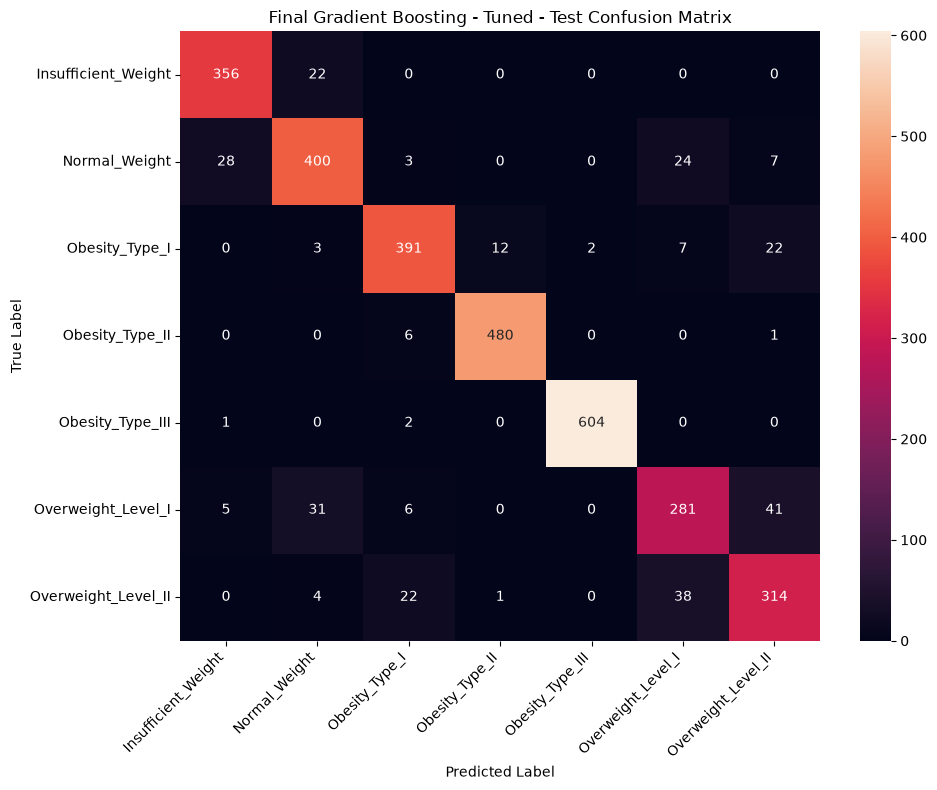

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

final_cm = confusion_matrix(
    y_test,
    final_test_pred,
    labels=class_names
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Final {best_model_name} - Test Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Save the Final Confusion Matrix

The confusion matrix is saved to:
`reports/generated/final_confusion_matrix.csv`.

Class names are retained as row and column labels so the counts
can be interpreted and reused in the project report.

In [46]:
final_cm_df = pd.DataFrame(
    final_cm,
    index=class_names,
    columns=class_names
)

final_cm_df.to_csv(
    REPORTS / "final_confusion_matrix.csv",
    index=True
)

print(
    "Saved:",
    REPORTS / "final_confusion_matrix.csv"
)

Saved: c:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\reports\generated\final_confusion_matrix.csv


## Save the Final Model Pipeline

The final fitted Gradient Boosting pipeline is saved to:
`models/obesity_risk_pipeline.joblib`.

The artifact contains both the fitted preprocessing steps and
the trained classifier. Loading this pipeline allows the application
to apply the same transformations when predicting new records.

The final pipeline expects the original 16 input features.
BMI was investigated separately and is not a model input.

In [47]:
import joblib
from pathlib import Path

model_dir = Path("../models")
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "obesity_risk_pipeline.joblib"

joblib.dump(final_model, model_path)

print("Saved:", model_path)

Saved: ..\models\obesity_risk_pipeline.joblib


### Check the Saved Model File

This cell displays whether the model file exists and its size
in megabytes.

These checks confirm that an artifact was written. Loading it
and checking its predictions are separate integration tests.

In [48]:
print("Model file exists:", model_path.exists())
print("Model size (MB):", round(model_path.stat().st_size / (1024 * 1024), 2))

Model file exists: True
Model size (MB): 0.88


## Save Final Model Metadata

Metadata documents the saved pipeline and the evidence supporting
its selection.

The JSON file records:
- The selected candidate and model family.
- The classifier's configured hyperparameters.
- Input feature names and counts before and after preprocessing.
- The seven target classes.
- Validation metrics used for model selection.
- Final test metrics.
- Training, validation, development, and test dataset sizes.
- The random seed, cross-validation folds, search candidate count,
  and scikit-learn version.

Validation metrics are taken from the selected comparison-table row.
Classifier parameters are extracted from the final fitted pipeline,
so the metadata follows whichever candidate was selected.

The metadata is saved to `models/model_metadata.json` for use
during explainability analysis, application integration, and reporting.

In [49]:
import json
import sklearn

# Record validation metrics and parameters of the selected model
selected_validation_metrics = best_model.to_dict()

selected_hyperparameters = {
    name: value
    for name, value in final_model.get_params().items()
    if name.startswith("classifier__")
}

metadata = {

    "project": "Obesity Risk Intelligence System",

    "selected_candidate": best_model_name,

    "model_family": best_model_name.replace(" - Tuned", ""),

    "configuration": selected_hyperparameters,

    # Feature information
    "predictive_features": list(X_train.columns),

    "predictive_feature_count": int(X_train.shape[1]),

    "transformed_feature_count": int(
        final_model.named_steps["preprocessor"]
        .transform(X_train)
        .shape[1]
    ),

    # Classes
    "target_classes": list(class_names),

    "target_class_count": len(class_names),

    "final_test_accuracy": float(
        final_test_metrics["Accuracy"]
    ),

    "final_test_balanced_accuracy": float(
        final_test_metrics["Balanced Accuracy"]
    ),

    "final_test_macro_f1": float(
        final_test_metrics["Macro F1"]
    ),

    "final_test_weighted_f1": float(
        final_test_metrics["Weighted F1"]
    ),

    "selection_metric": "Macro F1",

    "validation_metrics": {
        "Accuracy": float(selected_validation_metrics["Accuracy"]),
        "Balanced Accuracy": float(selected_validation_metrics["Balanced Accuracy"]),
        "Macro F1": float(selected_validation_metrics["Macro F1"]),
        "Weighted F1": float(selected_validation_metrics["Weighted F1"])
    },

    "dataset": {
        "training_samples": int(len(X_train)),
        "validation_samples": int(len(X_val)),
        "development_samples": int(len(X_dev)),
        "test_samples": int(len(X_test)),
        "raw_features": int(X_train.shape[1])
    },

    "reproducibility": {
        "random_seed": 42,
        "cross_validation_folds": 5,
        "tuning_candidates": 20,
        "scikit_learn_version": sklearn.__version__
    },

    "scikit_learn_version": sklearn.__version__
}

metadata_path = Path("../models/model_metadata.json")

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:", metadata_path)

Saved: ..\models\model_metadata.json


### Verify the Saved Metadata

The saved JSON file is opened again to confirm that it can be read.

The cell displays the selected model, selection metric, and final
test Macro F1 so the team can check the recorded values.

This verifies that the file is readable and exposes key metadata.
Consistency between the metadata, saved pipeline, and application
must also be checked during integration testing.

In [50]:
print("Metadata file exists:", metadata_path.exists())

with open(metadata_path, "r") as f:
    saved_metadata = json.load(f)

print("Model:", saved_metadata["selected_candidate"])
print("Selection metric:", saved_metadata["selection_metric"])
print("Test Macro F1:", saved_metadata["final_test_macro_f1"])

Metadata file exists: True
Model: Gradient Boosting - Tuned
Selection metric: Macro F1
Test Macro F1: 0.8973281823370796
